In [24]:
import os
from typing import Optional

from matplotlib import cm
from matplotlib import patches
from matplotlib import pyplot as plt
from matplotlib import ticker
import numpy as np


In [25]:
def plot_2d_map(coord_x: np.ndarray,
                coord_y: np.ndarray,
                values: np.ndarray,
               
                cbar:Optional[bool]=True) -> None:
    """Plots a 2D map for a plate with or without holes.

    Args:
        coord_x: A 1-dimensional numpy array containing the x-coordinates of all 
          points on the 2D mesh.
        coord_y: A 1-dimensional numpy array containing the y-coordinates of all 
          points on the 2D mesh.
        values: A 1-dimensional numpy array containing the values to be plotted 
          for all points on the 2D mesh.
        holes_info: A 2-dimensional numpy array containing the information of 
          the centers and radius of the holes. Each row should have 3 values: 
          x-coordinate of the center of the hole, y-coordinate of the center of
          the hole, and the radius of the hole. Default is None if the plate has 
          no holes.
    """

    # Create a figure and axes object
    _, axes = plt.subplots(figsize=(4, 4))

    # Choose the number of levels and color map
    levels = ticker.MaxNLocator(nbins=800).tick_values(np.min(values),
                                                       np.max(values))
    cmap = cm.get_cmap(name="jet", lut=None)

    # Add the stress map to the plot
    contour_set = axes.tricontourf(coord_x,
                                   coord_y,
                                   values,
                                   levels=levels,
                                   cmap=cmap)

    # Add color bar to the plot
    if cbar:
      c=plt.colorbar(contour_set)
      

    # Set the limits of the axes
    x_min, x_max = np.min(coord_x), np.max(coord_x)
    y_min, y_max = np.min(coord_y), np.max(coord_y)
    axes.set_xlim(x_min, x_max)
    axes.set_ylim(y_min, y_max)

    # Remove the axes
    plt.axis("off")

    # Show the plot
    plt.show()

def plot_mesh(coord_x1: np.ndarray, coord_y1: np.ndarray, 
              elements1: np.ndarray
              ) -> None:
    """Plots a triangular mesh.

    Args:
        coord_x: A 1-dimensional numpy array containing the x-coordinates of all
          points on the 2D mesh.
        coord_y: A 1-dimensional numpy array containing the y-coordinates of all
          points on the 2D mesh.
        elements: A 2-dimensional numpy array containing the indices of the 
          points that form each triangle element in the mesh.
    """

    # Create a figure and axes object
    _, ax = plt.subplots(figsize=(4, 4))

    

    # Set the limits of the axes
    x_min1, x_max1 = np.min(coord_x1), np.max(coord_x1)
    y_min1, y_max1 = np.min(coord_y1), np.max(coord_y1)
    ax.set_xlim(x_min1, x_max1)
    ax.set_ylim(y_min1, y_max1)
    
    width1, height1 = x_max1 - x_min1, y_max1 - y_min1
  

    rect1 = patches.Rectangle((x_min1, y_min1),
                             width1,
                             height1,
                             facecolor="lightgray")
   
    ax.add_patch(rect1)
  

    
    
    
            
    # Add the mesh to the plot
    ax.triplot(coord_x1, coord_y1, elements1, linewidth=0.1)
   



    

    # Remove the axes
    plt.axis("off")

    # Show the plot
    plt.show()






In [44]:
id=199

In [45]:
h_y=np.load("./data_boundary//"+str(id)+"//H_y.npy")
h_pos=np.load("./data_boundary//"+str(id)+"//H_mesh_geometry.npy")
h_topology=np.load("./data_boundary//"+str(id)+"//H_mesh_topology.npy")

l_y=np.load("./data_boundary//"+str(id)+"//L_y.npy")
l_pos=np.load("./data_boundary//"+str(id)+"//L_mesh_geometry.npy")
l_topology=np.load("./data_boundary//"+str(id)+"//L_mesh_topology.npy")

FileNotFoundError: [Errno 2] No such file or directory: './data_boundary//199//L_y.npy'

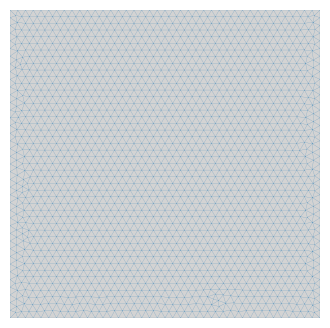

In [42]:
plot_mesh(h_pos[:,0],h_pos[:,1], h_topology)

/tmp/ipykernel_2218868/1392444497.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(name="jet", lut=None)


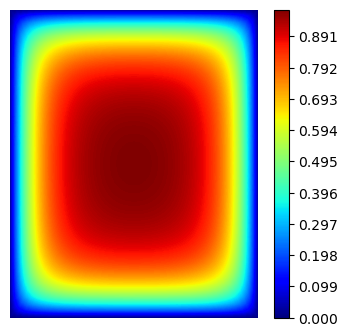

In [47]:
plot_2d_map(h_pos[:,0],h_pos[:,1], h_y.reshape(-1))